# EU AI Act Article 10 - HR Systems Compliance Tutorial

> **Legal position as at 6 September 2026.** The AI Act was amended by
> **Regulation (EU) 2026/1744** ("the Digital Omnibus on AI"), published
> 24 July 2026 and in force from 27 July 2026. That amendment **deleted
> Article 10(5)** and moved the legal basis for processing special categories
> of personal data for bias detection into a **new Article 4a**. Section 3 of
> this notebook has been rewritten accordingly. Check for later amendments
> before relying on any of it.
>
> Note also the timing: the Annex III high-risk obligations apply from
> **2 December 2027** for systems classified under Article 6(2) and
> **2 August 2028** under Article 6(1). Nothing here is yet enforceable
> against an HR system.

This notebook walks through five data governance requirements under **Article 10
of the EU AI Act** as they apply to high-risk AI systems used in HR and
recruitment. Article 10 is titled *"Data and data governance"*.

HR recruitment and performance management tools are listed as **high-risk AI
systems** (Annex III, point 4: recruitment and selection at 4(a), decisions on
terms, promotion, termination and performance evaluation at 4(b)). That means:

- Training, validation and test data must be **subject to data governance practices**
- Data must be **relevant, sufficiently representative, and to the best extent
  possible free of errors and complete** in view of the intended purpose
- Data must be **examined for possible biases** (10(2)(f)), and appropriate
  measures taken to **detect, prevent and mitigate** them (10(2)(g))
- Processing special categories of personal data to do that has its own narrow
  legal basis and conditions (**Article 4a**, since July 2026)

---

**Sections:**
1. Data Provenance Logging
2. Demographic Parity & Bias Testing
3. Special Category Data - the Article 4a conditions
4. Synthetic Data for Safe Bias Testing
5. Putting It Together - Compliance Checklist

In [1]:
# Setup — all dependencies are standard or widely available
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import hashlib
import json
import datetime
import warnings
from dataclasses import dataclass, field, asdict
from typing import List, Optional, Dict, Any
from io import StringIO

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Dependencies loaded successfully.')

Dependencies loaded successfully.


---
## Section 1: Data Provenance

### What Article 10 Requires

**Article 10(2)(a)** requires that training, validation, and test datasets be subject to *appropriate data governance and management practices*, including an examination of their **origin**. This is data provenance.

In practice this means:
- **Where** did the data come from? (source URL, internal system, third-party vendor)
- **When** was it collected?
- **Why** was it collected? (the original purpose — is this the same as your AI use?)
- **Has it changed?** (cryptographic hash to detect tampering or drift)

Without this, you cannot demonstrate to a notified body or market surveillance authority that your training data was appropriate for the task.

In [2]:
# DataProvenanceLog — records origin metadata for a dataset

@dataclass
class DataProvenanceLog:
    dataset_name: str
    source: str                    # URL or description
    collection_date: str           # ISO 8601
    intended_use: str              # original purpose at collection
    ai_use: str                    # intended use in this AI system
    file_path: Optional[str] = None
    file_hash: Optional[str] = None
    logged_at: str = field(default_factory=lambda: datetime.datetime.utcnow().isoformat())
    notes: str = ''

    def hash_file(self) -> None:
        """SHA-256 of the file this record names.

        The hash has to be of the actual dataset. A provenance record whose
        hash covers something else cannot detect tampering or drift, which is
        the only reason Article 10(2)(a) wants it.
        """
        if not self.file_path:
            raise ValueError(f"{self.dataset_name}: no file_path to hash")
        with open(self.file_path, 'rb') as fh:
            self.file_hash = hashlib.sha256(fh.read()).hexdigest()

    def purpose_mismatch_warning(self) -> Optional[str]:
        """Warn if original and AI intended uses look materially different."""
        if self.intended_use.lower() != self.ai_use.lower():
            return (f"WARNING: '{self.dataset_name}' was collected for \"{self.intended_use}\" "
                    f"but is being used for \"{self.ai_use}\". "
                    f"Article 10(2)(b) requires this to be examined and justified.")
        return None

print('DataProvenanceLog defined.')

DataProvenanceLog defined.


In [3]:
# Write the three datasets the provenance records refer to.
# Synthetic and seeded, so the hashes below are reproducible.

import os
os.makedirs('data', exist_ok=True)
rng_prov = np.random.default_rng(2024)

FIRST = ['Morgan','Alex','Jordan','Taylor','Casey','Riley','Avery','Quinn','Chris','Jamie','Drew','Sam']
LAST  = ['Smith','Brown','Garcia','Kim','Okafor','Patel','Chen','Johnson','Ali','Fischer','Dubois','Nguyen']
SKILLS = ['Python','Java','SQL','R','Excel','Tableau','Scala','Machine Learning','Project Management']
ROLES  = ['Data Analyst','Software Engineer','Product Manager','HR Specialist','Marketing Manager']

n1 = 200
pd.DataFrame({
    'candidate_id': [f'SYN-{1000+i}' for i in range(n1)],
    'name': [f'{a} {b}' for a, b in zip(rng_prov.choice(FIRST, n1), rng_prov.choice(LAST, n1))],
    'skills': ['; '.join(rng_prov.choice(SKILLS, size=rng_prov.integers(2, 5), replace=False)) for _ in range(n1)],
    'years_exp': rng_prov.integers(0, 20, n1),
    'applied_year': rng_prov.integers(2019, 2025, n1),
}).to_csv('data/resumes_corpus_2019_2024.csv', index=False)

n2 = 150
pd.DataFrame({
    'employee_id': [f'SYN-EMP-{2000+i}' for i in range(n2)],
    'rating': np.round(rng_prov.normal(3.6, 0.6, n2).clip(1, 5), 1),
    'year': rng_prov.choice([2022, 2023, 2024], n2),
    'reviewer_role': rng_prov.choice(['Line Manager', 'HR Business Partner'], n2),
}).to_csv('data/performance_reviews_2022_2024.csv', index=False)

n3 = 300
pd.DataFrame({
    'candidate_id': [f'SYN-{9000+i}' for i in range(n3)],
    'hired': rng_prov.binomial(1, 0.35, n3).astype(bool),
    'role': rng_prov.choice(ROLES, n3),
    'decision_year': rng_prov.integers(2015, 2024, n3),
}).to_csv('data/historical_hiring_decisions_2015_2023.csv', index=False)

for f in ('resumes_corpus_2019_2024.csv', 'performance_reviews_2022_2024.csv',
          'historical_hiring_decisions_2015_2023.csv'):
    print(f'wrote data/{f}')       # the rest of data/ belongs to notebooks/


wrote data/resumes_corpus_2019_2024.csv
wrote data/performance_reviews_2022_2024.csv
wrote data/historical_hiring_decisions_2015_2023.csv


In [4]:
# Log three typical HR datasets

logs = []

log1 = DataProvenanceLog(
    dataset_name='resumes_corpus_2019_2024',
    source='Internal ATS export — Workday, tenant: acme-corp',
    collection_date='2024-01-15',
    intended_use='Applicant tracking and recruiter review',
    ai_use='Training CV screening model to rank candidates for shortlisting',
    file_path='data/resumes_corpus_2019_2024.csv',
    notes='5-year rolling window. Excludes withdrawn applications.'
)
log1.hash_file()
logs.append(log1)

log2 = DataProvenanceLog(
    dataset_name='performance_reviews_2022_2024',
    source='HR Business Partner annual review exports — internal SharePoint',
    collection_date='2024-03-01',
    intended_use='Manager feedback and compensation decisions',
    ai_use='Feature in promotion likelihood model',
    file_path='data/performance_reviews_2022_2024.csv',
    notes='Manager scores only; self-assessments excluded.'
)
log2.hash_file()
logs.append(log2)

log3 = DataProvenanceLog(
    dataset_name='historical_hiring_decisions_2015_2023',
    source='Legacy HR database — Oracle HR, migrated to Snowflake 2022',
    collection_date='2024-02-10',
    intended_use='HR reporting and headcount planning',
    ai_use='Training labels (hired/not hired) for CV screening model',
    file_path='data/historical_hiring_decisions_2015_2023.csv',
    notes='Pre-2019 data may reflect pre-diversity-initiative hiring patterns. Flag for bias audit.'
)
log3.hash_file()
logs.append(log3)

# Check for purpose mismatches
for log in logs:
    warn = log.purpose_mismatch_warning()
    if warn:
        print(warn)

In [5]:
# Output provenance report as a DataFrame

provenance_df = pd.DataFrame([
    {
        'Dataset': l.dataset_name,
        'Source': l.source[:60] + '...' if len(l.source) > 60 else l.source,
        'Collection Date': l.collection_date,
        'AI Use': l.ai_use[:55] + '...' if len(l.ai_use) > 55 else l.ai_use,
        'SHA-256 (first 16)': l.file_hash[:16] if l.file_hash else 'NOT HASHED',
        'Logged At': l.logged_at[:19],
    }
    for l in logs
])

pd.set_option('display.max_colwidth', 70)
print('=== DATA PROVENANCE REPORT ===')
provenance_df

=== DATA PROVENANCE REPORT ===


,Dataset,Source,Collection Date,AI Use,SHA-256 (first 16),Logged At
0,resumes_corpus_2019_2024,"Internal ATS export — Workday, tenant: acme-corp",2024-01-15,Training CV screening model to rank candidates for shor...,da7922664a93f86e,2026-09-06T09:20:51
1,performance_reviews_2022_2024,HR Business Partner annual review exports — internal SharePo...,2024-03-01,Feature in promotion likelihood model,7e16cc231a9569f4,2026-09-06T09:20:51
2,historical_hiring_decisions_2015_2023,"Legacy HR database — Oracle HR, migrated to Snowflake 2022",2024-02-10,Training labels (hired/not hired) for CV screening mode...,d30f42bdf31f5346,2026-09-06T09:20:51


---
## Section 2: Demographic Parity Testing

### What Article 10 Requires

**Article 10(2)(f)** requires *"examination in view of possible biases that are
likely to affect the health and safety of persons, have a negative impact on
fundamental rights, or lead to discrimination prohibited under Union law"*.

**Article 10(2)(g)** then requires *"appropriate measures to detect, prevent and
mitigate possible biases identified according to point (f)"*. Examination and
mitigation are two separate obligations under two separate letters, and this
notebook does the examination in this section and the mitigation later.

**Article 10(3)** requires that datasets be *"relevant, sufficiently
representative, and to the best extent possible, free of errors and complete in
view of the intended purpose"*. Note the qualifiers: the standard is not
perfection.

Two standard metrics from fair-ML practice are used here:

- **Demographic Parity Difference (DPD):** the absolute difference in hire rates
  between groups.
- **Disparate Impact Ratio (DIR):** the ratio of hire rates between a group and
  the most-favoured group. The **four-fifths rule** flags DIR < 0.8.

The four-fifths rule is a **US EEOC convention** (Uniform Guidelines on Employee
Selection Procedures, 1978). It is a useful screen, it is **not** part of the AI
Act, and CJEU indirect-discrimination case law adopts no fixed ratio. It is used
here because it is concrete, not because it is the legal test.

We implement both from scratch - no fairness library required.

In [6]:
# Generate synthetic hiring dataset — 500 candidates
# We inject realistic-looking (but not real) demographic patterns

n = 500
rng = np.random.default_rng(42)

age_groups = rng.choice(['18-30', '31-45', '46-60', '60+'], size=n, p=[0.35, 0.40, 0.20, 0.05])
genders = rng.choice(['Woman', 'Man', 'Non-binary'], size=n, p=[0.48, 0.49, 0.03])
ethnicities = rng.choice(
    ['White', 'Asian', 'Black', 'Hispanic', 'Other'],
    size=n, p=[0.55, 0.18, 0.12, 0.10, 0.05]
)
years_exp = rng.integers(0, 20, size=n)
education = rng.choice(['High school', 'Bachelor', 'Master', 'PhD'], size=n, p=[0.15, 0.50, 0.28, 0.07])

# Hire probability — meritocratic base + injected biases
edu_bonus = {'High school': -0.05, 'Bachelor': 0.0, 'Master': 0.08, 'PhD': 0.12}
base_prob = 0.30 + (years_exp / 20) * 0.25 + np.array([edu_bonus[e] for e in education])

# Injected biases (representing historical discrimination in training labels)
gender_bias = np.where(genders == 'Woman', -0.07, np.where(genders == 'Non-binary', -0.12, 0.0))
age_bias = np.where(age_groups == '60+', -0.15, np.where(age_groups == '46-60', -0.05, 0.0))
ethnicity_bias = np.where(ethnicities == 'Black', -0.10,
                 np.where(ethnicities == 'Hispanic', -0.06, 0.0))

hire_prob = np.clip(base_prob + gender_bias + age_bias + ethnicity_bias, 0.05, 0.95)
hired = rng.binomial(1, hire_prob).astype(bool)

df = pd.DataFrame({
    'age_group': age_groups,
    'gender': genders,
    'ethnicity': ethnicities,
    'years_experience': years_exp,
    'education_level': education,
    'hired': hired
})

SENSITIVE_ALL = ['gender', 'age_group', 'ethnicity']

print(f'Dataset shape: {df.shape}')
print(f'Overall hire rate: {df.hired.mean():.1%}')
df.head()

Dataset shape: (500, 6)
Overall hire rate: 37.8%


,age_group,gender,ethnicity,years_experience,education_level,hired
0,46-60,Man,White,15,Bachelor,False
1,31-45,Man,White,13,Bachelor,True
2,46-60,Man,White,18,Master,True
3,31-45,Man,White,19,Master,True
4,18-30,Man,Asian,14,Bachelor,True


In [7]:
# Implement DPD and DIR from scratch

def compute_hire_rates(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """Compute hire rate per group."""
    rates = df.groupby(group_col)['hired'].agg(['mean', 'count', 'sum']).reset_index()
    rates.columns = [group_col, 'hire_rate', 'n_candidates', 'n_hired']
    rates = rates.sort_values('hire_rate', ascending=False).reset_index(drop=True)
    return rates


def demographic_parity_difference(rates: pd.DataFrame, group_col: str) -> float:
    """DPD: max hire rate minus min hire rate across all groups."""
    return rates['hire_rate'].max() - rates['hire_rate'].min()


def disparate_impact_ratio(rates: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """DIR: each group's hire rate divided by the most-favoured group's hire rate."""
    max_rate = rates['hire_rate'].max()
    result = rates.copy()
    result['DIR'] = result['hire_rate'] / max_rate
    result['FLAG_80_RULE'] = result['DIR'] < 0.80
    return result


def bias_report(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    rates = compute_hire_rates(df, group_col)
    report = disparate_impact_ratio(rates, group_col)
    dpd = demographic_parity_difference(rates, group_col)
    print(f'\n--- {group_col.upper()} ---')
    print(f'Demographic Parity Difference: {dpd:.3f}')
    flagged = report[report['FLAG_80_RULE']]
    if not flagged.empty:
        for _, row in flagged.iterrows():
            print(f'  ⚠️  FOUR-FIFTHS RULE VIOLATION: {row[group_col]} — DIR = {row["DIR"]:.2f} (hire rate {row["hire_rate"]:.1%})')
    else:
        print('  ✓ No group falls below the 80% threshold')
    return report


gender_report = bias_report(df, 'gender')
age_report    = bias_report(df, 'age_group')
eth_report    = bias_report(df, 'ethnicity')


--- GENDER ---
Demographic Parity Difference: 0.111
  ⚠️  FOUR-FIFTHS RULE VIOLATION: Woman — DIR = 0.78 (hire rate 33.5%)
  ⚠️  FOUR-FIFTHS RULE VIOLATION: Non-binary — DIR = 0.74 (hire rate 31.6%)

--- AGE_GROUP ---
Demographic Parity Difference: 0.127
  ⚠️  FOUR-FIFTHS RULE VIOLATION: 60+ — DIR = 0.67 (hire rate 26.3%)

--- ETHNICITY ---
Demographic Parity Difference: 0.127
  ⚠️  FOUR-FIFTHS RULE VIOLATION: Other — DIR = 0.78 (hire rate 31.0%)
  ⚠️  FOUR-FIFTHS RULE VIOLATION: Hispanic — DIR = 0.68 (hire rate 27.3%)


### Does the test actually work?

The sections above ran the four-fifths rule and reported violations. That is half
a compliance check. The other half is asking whether the test was right, and this
dataset can answer it, because the penalties were injected in code above.

The comparison has to be made carefully. "A penalty was injected" is **not** the
same as "the four-fifths rule should have flagged it": a penalty of 0.05 does not
push a group below 0.80, so not flagging it is the rule behaving correctly. The
reference below is `DIR pop` - the disparate impact ratio the generator implies
in the population, computed by running it at 400,000 rows where sampling noise
is negligible. A group is something the rule *should* catch only if its
population DIR is below 0.80.

In [8]:
# Score the test against what the four-fifths rule SHOULD have caught.
#
# An earlier version scored "was a penalty injected?" against "was it flagged?".
# That is the wrong criterion: a small penalty does not put a group below the
# 0.80 line, so failing to flag it is the rule working correctly, not a miss.
# The right reference is the DIR the generator implies in the population, which
# we get by running it at a size where sampling noise is negligible.

def population_rates(n=400_000, seed=0):
    """The same generator, large enough that the DIR is the population value."""
    r = np.random.default_rng(seed)
    ag = r.choice(['18-30','31-45','46-60','60+'], n, p=[.35,.40,.20,.05])
    ge = r.choice(['Woman','Man','Non-binary'], n, p=[.48,.49,.03])
    et = r.choice(['White','Asian','Black','Hispanic','Other'], n, p=[.55,.18,.12,.10,.05])
    yr = r.integers(0, 20, n)
    ed = r.choice(['High school','Bachelor','Master','PhD'], n, p=[.15,.50,.28,.07])
    bonus = {'High school':-.05,'Bachelor':0.,'Master':.08,'PhD':.12}
    base = 0.30 + (yr/20)*0.25 + np.array([bonus[e] for e in ed])
    gb = np.where(ge=='Woman',-.07, np.where(ge=='Non-binary',-.12, 0.))
    ab = np.where(ag=='60+',-.15, np.where(ag=='46-60',-.05, 0.))
    eb = np.where(et=='Black',-.10, np.where(et=='Hispanic',-.06, 0.))
    prob = np.clip(base+gb+ab+eb, .05, .95)
    return pd.DataFrame({'age_group':ag,'gender':ge,'ethnicity':et,'p':prob})


pop = population_rates()
expected = {}
for attr in ('gender','age_group','ethnicity'):
    m = pop.groupby(attr)['p'].mean()
    expected[attr] = (m / m.max()).to_dict()

rows = []
for attr in ('gender','age_group','ethnicity'):
    stats = df.groupby(attr)['hired'].agg(['mean','size'])
    ref = stats['mean'].max()
    for grp in stats.index:
        dir_obs = stats.loc[grp,'mean'] / ref
        dir_exp = expected[attr][grp]
        flagged, should = dir_obs < 0.80, dir_exp < 0.80
        verdict = ('true positive' if flagged and should else
                   'FALSE POSITIVE' if flagged else
                   'FALSE NEGATIVE' if should else 'true negative')
        rows.append(dict(attribute=attr, group=grp, n=stats.loc[grp,'size'],
                         rate=stats.loc[grp,'mean'], dir_obs=dir_obs,
                         dir_exp=dir_exp, flagged=flagged, verdict=verdict))

validation = pd.DataFrame(rows)
print(f"{'attribute':<11}{'group':<12}{'n':>5}{'rate':>7}{'DIR obs':>9}{'DIR pop':>9}"
      f"  {'flagged':<8}verdict")
for r in rows:
    print(f"{r['attribute']:<11}{r['group']:<12}{r['n']:>5}{r['rate']:>7.1%}"
          f"{r['dir_obs']:>9.2f}{r['dir_exp']:>9.2f}  "
          f"{('YES' if r['flagged'] else 'no'):<8}{r['verdict']}")

c = validation.verdict.value_counts()
print(f"\n{len(validation)} groups: {c.get('true positive',0)} true positive, "
      f"{c.get('true negative',0)} true negative, "
      f"{c.get('FALSE NEGATIVE',0)} FALSE NEGATIVE, {c.get('FALSE POSITIVE',0)} FALSE POSITIVE")
print(f"The four-fifths rule got "
      f"{c.get('FALSE NEGATIVE',0)+c.get('FALSE POSITIVE',0)} of {len(validation)} "
      f"groups wrong at n={len(df)}.")

attribute  group           n   rate  DIR obs  DIR pop  flagged verdict


gender     Man           239  42.7%     1.00     1.00  no      true negative
gender     Non-binary     19  31.6%     0.74     0.71  YES     true positive
gender     Woman         242  33.5%     0.78     0.83  YES     FALSE POSITIVE
age_group  18-30         176  38.6%     0.99     1.00  no      true negative
age_group  31-45         200  37.5%     0.96     1.00  no      true negative
age_group  46-60         105  39.0%     1.00     0.87  no      true negative
age_group  60+            19  26.3%     0.67     0.61  YES     true positive
ethnicity  Asian          84  39.3%     0.98     1.00  no      true negative
ethnicity  Black          54  38.9%     0.97     0.74  no      FALSE NEGATIVE
ethnicity  Hispanic       55  27.3%     0.68     0.84  YES     FALSE POSITIVE
ethnicity  Other          29  31.0%     0.78     1.00  YES     FALSE POSITIVE
ethnicity  White         278  39.9%     1.00     0.99  no      true negative

12 groups: 2 true positive, 6 true negative, 1 FALSE NEGATIVE, 3 FALSE

### Put an interval on it

Every DIR above is a ratio of two sample proportions, and several of them are
computed on fewer than 30 people. A point estimate from 19 candidates is not a
measurement, and the four-fifths rule has no notion of uncertainty built into it:
it compares a number to 0.80 and returns a verdict.

Two things follow, and both are measurable. A bootstrap interval says how much
the observed DIR could move on resampling. A power calculation says how many
candidates per group you would need before the rule could reliably see a real
violation.

In [9]:
def dir_interval(data, col, B=3000, seed=0):
    """Bootstrap 95% interval for each group's disparate impact ratio."""
    r = np.random.default_rng(seed)
    groups = sorted(data[col].unique())
    codes = pd.Categorical(data[col], categories=groups).codes
    hired = data['hired'].to_numpy().astype(float)
    m = len(data)
    draws = np.empty((B, len(groups)))
    for t in range(B):
        idx = r.integers(0, m, m)
        c, h = codes[idx], hired[idx]
        rates = np.array([h[c == k].mean() if (c == k).any() else np.nan
                          for k in range(len(groups))])
        draws[t] = rates / np.nanmax(rates)
    lo, hi = np.nanpercentile(draws, [2.5, 97.5], axis=0)
    return dict(zip(groups, zip(lo, hi)))


print(f"{'attribute':<11}{'group':<12}{'n':>5}{'DIR':>7}   {'95% interval':<16}verdict")
for attr in SENSITIVE_ALL:
    ci = dir_interval(df, attr)
    stats = df.groupby(attr)['hired'].agg(['mean', 'size'])
    ref = stats['mean'].max()
    for grp in stats.index:
        d = stats.loc[grp, 'mean'] / ref
        lo, hi = ci[grp]
        if hi < 0.80:
            v = 'violation'
        elif lo > 0.80:
            v = 'clear'
        else:
            v = 'CANNOT TELL'
        print(f'{attr:<11}{grp:<12}{stats.loc[grp, "size"]:>5}{d:>7.2f}   '
              f'[{lo:.2f}, {hi:.2f}]{"":<6}{v}')


attribute  group           n    DIR   95% interval    verdict


gender     Man           239   1.00   [0.77, 1.00]      CANNOT TELL
gender     Non-binary     19   0.74   [0.26, 1.00]      CANNOT TELL
gender     Woman         242   0.78   [0.58, 0.98]      CANNOT TELL
age_group  18-30         176   0.99   [0.71, 1.00]      CANNOT TELL
age_group  31-45         200   0.96   [0.69, 1.00]      CANNOT TELL
age_group  46-60         105   1.00   [0.71, 1.00]      CANNOT TELL
age_group  60+            19   0.67   [0.16, 1.00]      CANNOT TELL


ethnicity  Asian          84   0.98   [0.64, 1.00]      CANNOT TELL
ethnicity  Black          54   0.97   [0.58, 1.00]      CANNOT TELL
ethnicity  Hispanic       55   0.68   [0.35, 0.95]      CANNOT TELL
ethnicity  Other          29   0.78   [0.34, 1.00]      CANNOT TELL
ethnicity  White         278   1.00   [0.71, 1.00]      CANNOT TELL


Read the `verdict` column. **Not one of the twelve groups can be classified.**
Every interval crosses 0.80, including `Black` at [0.58, 1.00] and `Non-binary`
at [0.26, 1.00].

That is the real state of a four-fifths test on 500 candidates, and it is a
different statement from the one in Section 2. There the rule got four of twelve
groups wrong. Here the point is that it never had the information to get any of
them right: the answer it printed was a coin toss dressed as a measurement.

Nothing in the report the notebook generates carries this column.

### How many candidates would you need?

Simulate the rule itself. Two groups, a reference hire rate of 40%, a true
disparate impact ratio fixed in advance, and the question is how often the
four-fifths rule returns the right answer at a given group size.

`DIR pop = 0.74` is the value the generator implies for `Black`, so this is the
violation that is actually in the file. `DIR pop = 1.00` is a group with no
disparity at all, and the column for it is the false-alarm rate.

In [10]:
def rule_fires(true_dir, n_group, ref_rate=0.40, trials=8000, seed=0):
    """How often the four-fifths rule flags, at this group size and true ratio."""
    r = np.random.default_rng(seed)
    ref = r.binomial(n_group, ref_rate, trials) / n_group
    grp = r.binomial(n_group, ref_rate * true_dir, trials) / n_group
    with np.errstate(divide='ignore', invalid='ignore'):
        observed = np.where(ref > 0, grp / ref, np.nan)
    return np.nanmean(observed < 0.80)


print(f"{'n per group':>12}{'detects DIR 0.74':>20}{'false alarm at DIR 1.00':>26}")
for n_group in (20, 50, 100, 200, 500, 1000, 2000):
    print(f'{n_group:>12}{rule_fires(0.74, n_group):>19.0%}'
          f'{rule_fires(1.00, n_group):>26.0%}')
print('\n  the four-fifths rule needs roughly 500 per group before it detects a real\n'
      '  0.74 disparity more often than not, and its false-alarm rate only falls\n'
      '  below 5% somewhere past 200')


 n per group    detects DIR 0.74   false alarm at DIR 1.00
          20                55%                       27%
          50                61%                       19%
         100                66%                       10%
         200                71%                        3%
         500                81%                        0%
        1000                90%                        0%
        2000                96%                        0%

  the four-fifths rule needs roughly 500 per group before it detects a real
  0.74 disparity more often than not, and its false-alarm rate only falls
  below 5% somewhere past 200


### The objection you will actually get

"The gap disappears once you control for role and level." Every audit meets it.
The method is a conditional disparate impact ratio: compute the same rule inside
each stratum of a legitimate feature.

Barocas, Hardt & Narayanan are blunt about the catch. What you condition on
decides the verdict, and you must not condition on the mechanism of the
discrimination itself. If women are steered into lower-paid roles and you control
for role, the disparity vanishes on paper and the steering is what caused it.

In [11]:
for control in ('education_level', 'experience_band'):
    if control == 'experience_band':
        df[control] = pd.qcut(df['years_experience'], 3,
                              labels=['low exp', 'mid exp', 'high exp'])
    print(f'\nDIR for Woman, conditioned on {control}')
    for level, sub in df.groupby(control, observed=True):
        m = sub.groupby('gender')['hired'].mean()
        if 'Woman' not in m.index or len(sub) < 20:
            continue
        print(f'  {str(level):<14} n={len(sub):>4}   DIR = {m["Woman"] / m.max():.2f}')
    m = df.groupby('gender')['hired'].mean()
    print(f'  {"unconditional":<14} n={len(df):>4}   DIR = {m["Woman"] / m.max():.2f}')



DIR for Woman, conditioned on education_level
  Bachelor       n= 264   DIR = 0.84
  High school    n=  75   DIR = 0.51
  Master         n= 125   DIR = 0.68
  PhD            n=  36   DIR = 0.75
  unconditional  n= 500   DIR = 0.78

DIR for Woman, conditioned on experience_band
  low exp        n= 174   DIR = 0.98
  mid exp        n= 163   DIR = 0.70
  high exp       n= 163   DIR = 0.68
  unconditional  n= 500   DIR = 0.78


The unconditional DIR for `Woman` is 0.78. Conditioned on education it runs from
**0.51** among high-school candidates to **0.84** among bachelor's candidates -
one stratum passes the rule comfortably and another fails it badly. Conditioned
on experience it runs 0.98 / 0.70 / 0.68.

Most of that spread is noise: conditioning splits 500 people into four boxes and
the intervals above were already too wide at 500. That is the practical lesson
rather than an aside. Conditional analysis multiplies the group-size problem, and
it hands whoever is arguing a choice of stratification that changes the verdict.

Ask which control was chosen, and when. A control picked after seeing the result
is not a control.

### Intersections

Article 10(2)(f) says biases that lead to discrimination prohibited under Union
law. Discrimination does not arrive one attribute at a time, and a system can
pass on gender, pass on ethnicity, and fail on the combination.

The reason nobody runs this is visible in the `n` column.

In [12]:
cross = df.pivot_table(index='gender', columns='ethnicity', values='hired',
                       aggfunc=['size', 'mean'])
sizes = cross['size'].fillna(0).astype(int)
rates = cross['mean']

print('hire rate, with group size in brackets\n')
print(f'{"":<12}' + ''.join(f'{c:>16}' for c in rates.columns))
for g in rates.index:
    row = ''.join(
        ('        -       ' if sizes.loc[g, c] == 0
         else f'{rates.loc[g, c]:>10.0%} ({sizes.loc[g, c]:>2})')
        for c in rates.columns)
    print(f'{g:<12}{row}')

small = int((sizes.values > 0).sum() - (sizes.values >= 10).sum())
print(f'\n{sizes.size} cells, {int((sizes.values == 0).sum())} empty, '
      f'{small} with fewer than 10 candidates.')
print('A hire rate on 4 people is not a rate. Intersectional testing at n=500 is\n'
      'not a thing you can do, and saying so is more useful than a table of noise.')


hire rate, with group size in brackets

                       Asian           Black        Hispanic           Other           White
Man                43% (42)       46% (28)       17% (18)       42% (12)       45% (139)
Non-binary         33% ( 3)       50% ( 2)       40% ( 5)        -              22% ( 9)
Woman              36% (39)       29% (24)       31% (32)       24% (17)       35% (130)

15 cells, 1 empty, 4 with fewer than 10 candidates.
A hire rate on 4 people is not a rate. Intersectional testing at n=500 is
not a thing you can do, and saying so is more useful than a table of noise.


### The test that is not a rate: change the name, keep the CV

Everything above is a rate comparison between groups of different people. The
other family of evidence intervenes on one input and holds the rest fixed, which
is the resume audit - Bertrand & Mullainathan (2004) posted identical CVs under
different names and measured the callback gap.

You cannot do that to real applicants, but you can do it to a **model**, and for
a deployed screener it is the sharper test. Same candidate, same experience, same
education, different name.

Barocas, Hardt & Narayanan's caution goes next to it: flipping an attribute does
not generally produce the counterfactual you care about, because in the world a
different name comes with a different life. What it does test cleanly is whether
the *system in front of you* keys on the name.

In [13]:
from sklearn.linear_model import LogisticRegression

MALE_NAMES = ['Andreas', 'Lukas', 'Stefan', 'Matthias', 'Tobias', 'Jonas']
FEMALE_NAMES = ['Anna', 'Julia', 'Sabine', 'Katrin', 'Lena', 'Miriam']
SURNAMES = {'White': ['Fischer', 'Wagner', 'Meier', 'Schmidt'],
            'Black': ['Okafor', 'Mensah', 'Diallo', 'Abebe'],
            'Hispanic': ['Garcia', 'Morales', 'Ortiz', 'Ramirez'],
            'Asian': ['Nguyen', 'Kim', 'Chen', 'Patel'],
            'Other': ['Dubois', 'Rossi', 'Novak', 'Haddad']}

rng_name = np.random.default_rng(7)
df['first_name'] = [rng_name.choice(FEMALE_NAMES if g == 'Woman' else MALE_NAMES)
                    for g in df['gender']]
df['surname'] = [rng_name.choice(SURNAMES[e]) for e in df['ethnicity']]

SCREEN = ['first_name', 'surname', 'years_experience', 'education_level']
DUMMIES = ['first_name', 'surname', 'education_level']


def design(frame):
    return pd.get_dummies(frame[SCREEN], columns=DUMMIES)


base_design = design(df)
screener = LogisticRegression(max_iter=2000).fit(base_design, df['hired'])
cut = np.quantile(screener.predict_proba(base_design)[:, 1], 1 - df['hired'].mean())


def score(frame):
    return screener.predict_proba(
        design(frame).reindex(columns=base_design.columns, fill_value=0))[:, 1]


p_before = score(df)

flipped = df.copy()
flipped['first_name'] = [rng_name.choice(MALE_NAMES if g == 'Woman' else FEMALE_NAMES)
                         for g in df['gender']]
p_gender = score(flipped)

flipped = df.copy()
flipped['surname'] = [rng_name.choice(SURNAMES['White'] if e != 'White'
                                      else SURNAMES['Black']) for e in df['ethnicity']]
p_ethnicity = score(flipped)

print('same CV, one field changed. n=500, the screener never saw gender or '
      'ethnicity as a column\n')
print(f"{'':<34}{'mean score':>12}{'shortlisted':>13}")
print(f"{'as submitted':<34}{p_before.mean():>12.3f}{(p_before >= cut).mean():>13.1%}")
for label, p_new in (('first name swapped', p_gender),
                     ('surname swapped', p_ethnicity)):
    changed = int(((p_before >= cut) != (p_new >= cut)).sum())
    print(f'{label:<34}{p_new.mean():>12.3f}{(p_new >= cut).mean():>13.1%}'
          f'    {changed} of 500 decisions flip')

# Placebo: swap each name for a different one from the SAME pool. Nothing about
# the candidate's group changes, so whatever moves here is name noise, and it is
# the yardstick for the two rows above.
placebo = df.copy()
placebo['first_name'] = [rng_name.choice(FEMALE_NAMES if g == 'Woman' else MALE_NAMES)
                         for g in df['gender']]
placebo['surname'] = [rng_name.choice(SURNAMES[e]) for e in df['ethnicity']]
p_placebo = score(placebo)
print(f"{'placebo, same-pool name':<34}{p_placebo.mean():>12.3f}"
      f"{(p_placebo >= cut).mean():>13.1%}"
      f"    {int(((p_before >= cut) != (p_placebo >= cut)).sum())} of 500 decisions flip")

women = df['gender'] == 'Woman'
print(f'\nwomen given a male first name: mean score '
      f'{p_before[women].mean():.3f} -> {p_gender[women].mean():.3f}')
black = df['ethnicity'] == 'Black'
print(f'Black candidates given a white surname: mean score '
      f'{p_before[black].mean():.3f} -> {p_ethnicity[black].mean():.3f}')


same CV, one field changed. n=500, the screener never saw gender or ethnicity as a column

                                    mean score  shortlisted
as submitted                             0.378        37.8%
first name swapped                       0.370        36.6%    114 of 500 decisions flip
surname swapped                          0.417        46.6%    134 of 500 decisions flip
placebo, same-pool name                  0.383        37.8%    106 of 500 decisions flip

women given a male first name: mean score 0.339 -> 0.403
Black candidates given a white surname: mean score 0.370 -> 0.378


### Read the placebo row first

`placebo` swaps every name for a different name from the **same** pool, so
nothing about the candidate's group changes. It still flips **106 of 500**
decisions. That is the noise floor of a logistic model fitted to 500 rows with
name dummies in it, and it is most of the 114 and 134 in the two rows above.

So the flip counts say nothing. What survives the comparison is the group mean:

- **women given a male first name: 0.339 to 0.403**, a shift of +0.064 against a
  placebo shift of +0.005. That is the finding.
- **Black candidates given a white surname: 0.370 to 0.378**, +0.008. That is not
  distinguishable from the placebo, and it should not be reported as an effect.

The screener was given a name, an experience count and an education level. It was
never given gender. It learned gender anyway, because the first name carries it
and the historical labels carry the penalty. It did not measurably learn
ethnicity from the surname at this sample size, which is a statement about n=500
and not about surnames.

This is notebook 1's finding reached without a single group rate, and it is the
version an HR team can act on: it names a field, it produces a per-candidate
result, and it does not need 500 people in every group. Two limits stay attached.
The model is fitted on 500 rows, so treat magnitudes as illustrative. And
removing the name does not fix it - notebook 1 is the demonstration that the next
field takes over.


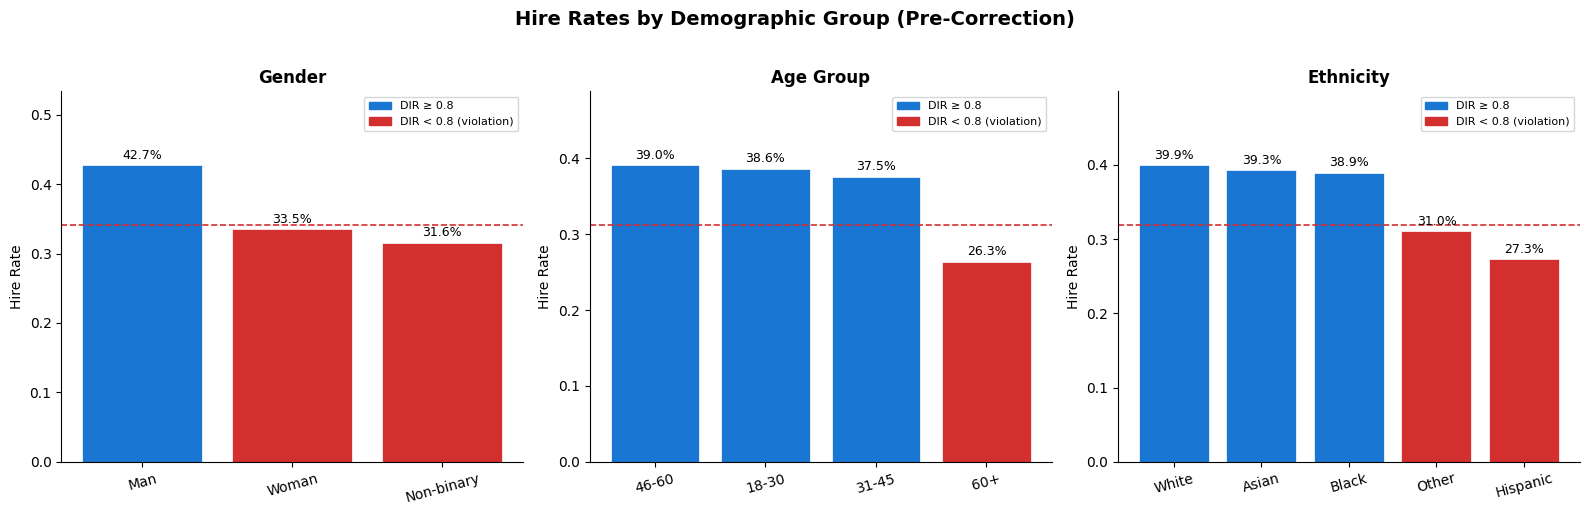

Chart saved as hire_rates_pre_correction.png


In [14]:
# Visualise hire rates by each demographic dimension

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Hire Rates by Demographic Group (Pre-Correction)', fontsize=14, fontweight='bold', y=1.02)

for ax, report, group_col, title in zip(
    axes,
    [gender_report, age_report, eth_report],
    ['gender', 'age_group', 'ethnicity'],
    ['Gender', 'Age Group', 'Ethnicity']
):
    colors = ['#d32f2f' if flag else '#1976D2' for flag in report['FLAG_80_RULE']]
    bars = ax.bar(report[group_col], report['hire_rate'], color=colors, edgecolor='white', linewidth=0.5)
    
    # 80% rule reference line (80% of max)
    threshold = report['hire_rate'].max() * 0.80
    ax.axhline(threshold, color='#d32f2f', linestyle='--', linewidth=1.2, label=f'80% threshold ({threshold:.1%})')
    
    # Value labels
    for bar, rate in zip(bars, report['hire_rate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{rate:.1%}', ha='center', va='bottom', fontsize=9)
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Hire Rate')
    ax.set_ylim(0, min(1.0, report['hire_rate'].max() * 1.25))
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=8)

    flagged_patch = mpatches.Patch(color='#d32f2f', label='DIR < 0.8 (violation)')
    ok_patch = mpatches.Patch(color='#1976D2', label='DIR ≥ 0.8')
    ax.legend(handles=[ok_patch, flagged_patch], fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('hire_rates_pre_correction.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved as hire_rates_pre_correction.png')

### Correcting it - and what correction costs

Article 10(2)(f) is the examination. **Article 10(2)(g)** is the separate
obligation to take *"appropriate measures to detect, prevent and mitigate"* the
biases found. This section does (g).

Two warnings before the code.

**A correction that only removes selections is not a correction.** If your
method can lower the advantaged group's rate but can never raise the
disadvantaged group's, you will reach parity by making everyone worse off. That
is what this notebook did until it was checked, and it is worth keeping the
failure visible rather than quietly deleting it.

**Post-processing sets different thresholds for different groups.** That is a
real method with a real cost, and notebook 3 in `notebooks/` shows the cost:
equalising one thing opens a gap somewhere else, and two people with the same
score can get different answers. Whether that is acceptable is a legal and
political question, not a technical one.

In [15]:
# Mitigation under Article 10(2)(g).
#
# An earlier version of this cell multiplied the *observed label* by a weight.
# Because `hired` is 0 or 1, that gave every rejected candidate p=0: nobody who
# was rejected could ever be hired, so the only thing it could do was un-hire
# people. It closed the gap by lowering the advantaged group's rate, took the
# overall hire rate from 37.8% to 32.0%, and introduced a fresh four-fifths
# violation that the checklist below then reported. That is levelling down, and
# it is the failure mode Corbett-Davies and Goel warn about.
#
# What follows instead is post-processing (Hardt, Price & Srebro 2016): score
# candidates on legitimate features only, then choose a per-group threshold so
# that selection rates match. It can promote as well as demote.

from sklearn.linear_model import LogisticRegression

SENSITIVE = ['gender', 'age_group', 'ethnicity']
LEGITIMATE = ['years_experience', 'education_level']

X_score = pd.get_dummies(df[LEGITIMATE], drop_first=True)
score = LogisticRegression(max_iter=1000).fit(X_score, df['hired']).predict_proba(X_score)[:, 1]
df['score'] = score

target_rate = df['hired'].mean()          # hold the overall hire rate fixed

# Thresholds are set on GENDER ONLY. Three attributes cannot all be equalised
# by one per-group threshold rule unless you threshold on the joint cell, and at
# n=500 the joint cells (3 x 4 x 5) hold a handful of people each. So this
# corrects gender and leaves age and ethnicity to whatever the score does. The
# next cell measures what that costs, because it is not nothing.
GROUP_COL = 'gender'

corrected = np.zeros(len(df), dtype=bool)
for group, idx in df.groupby(GROUP_COL).groups.items():
    idx = np.asarray(idx)
    cut = np.quantile(score[idx], 1 - target_rate)
    corrected[idx] = score[idx] >= cut

df['hired_corrected'] = corrected

print(f'Overall hire rate - original:  {df["hired"].mean():.1%}')
print(f'Overall hire rate - corrected: {df["hired_corrected"].mean():.1%}')
gained = int((~df['hired'] & df['hired_corrected']).sum())
lost = int((df['hired'] & ~df['hired_corrected']).sum())
print(f'  candidates newly hired: {gained}    no longer hired: {lost}')
for attr in SENSITIVE:
    print(f'\n{attr:<14}{"before":>9}{"after":>9}{"DIR before":>12}{"DIR after":>11}')
    b = df.groupby(attr)['hired'].mean()
    a_ = df.groupby(attr)['hired_corrected'].mean()
    for group in b.index:
        print(f'{group:<14}{b[group]:>9.1%}{a_[group]:>9.1%}'
              f'{b[group] / b.max():>12.2f}{a_[group] / a_.max():>11.2f}')

Overall hire rate - original:  37.8%
Overall hire rate - corrected: 38.6%
  candidates newly hired: 90    no longer hired: 86

gender           before    after  DIR before  DIR after
Man               42.7%    38.9%        1.00       1.00
Non-binary        31.6%    36.8%        0.74       0.95
Woman             33.5%    38.4%        0.78       0.99

age_group        before    after  DIR before  DIR after
18-30             38.6%    35.8%        0.99       0.80
31-45             37.5%    39.0%        0.96       0.87
46-60             39.0%    44.8%        1.00       1.00
60+               26.3%    26.3%        0.67       0.59

ethnicity        before    after  DIR before  DIR after
Asian             39.3%    38.1%        0.98       0.91
Black             38.9%    27.8%        0.97       0.67
Hispanic          27.3%    36.4%        0.68       0.87
Other             31.0%    34.5%        0.78       0.83
White             39.9%    41.7%        1.00       1.00


### What the correction did not touch

The rule above sets thresholds on gender. It never looks at age or ethnicity, so
under the corrected decision the *population* rate of every age and ethnicity
group is the same by construction. Any four-fifths flag those attributes raise
after correction is sampling noise at n=500 and nothing else.

The checklist in Section 5 does not know that. It runs on the corrected file and
reports whatever it finds. Run the whole thing 200 times and see how often it
reports a violation on an attribute the corrected rule cannot see.

In [16]:
def one_seed(seed):
    """Regenerate, correct on gender only, and return the flags per attribute."""
    r = np.random.default_rng(seed)
    ag = r.choice(['18-30', '31-45', '46-60', '60+'], n, p=[.35, .40, .20, .05])
    ge = r.choice(['Woman', 'Man', 'Non-binary'], n, p=[.48, .49, .03])
    et = r.choice(['White', 'Asian', 'Black', 'Hispanic', 'Other'], n,
                  p=[.55, .18, .12, .10, .05])
    yr = r.integers(0, 20, n)
    ed = r.choice(['High school', 'Bachelor', 'Master', 'PhD'], n,
                  p=[.15, .50, .28, .07])
    bonus = {'High school': -.05, 'Bachelor': 0., 'Master': .08, 'PhD': .12}
    base = 0.30 + (yr / 20) * 0.25 + np.array([bonus[e] for e in ed])
    gb = np.where(ge == 'Woman', -.07, np.where(ge == 'Non-binary', -.12, 0.))
    ab = np.where(ag == '60+', -.15, np.where(ag == '46-60', -.05, 0.))
    eb = np.where(et == 'Black', -.10, np.where(et == 'Hispanic', -.06, 0.))
    d = pd.DataFrame({'age_group': ag, 'gender': ge, 'ethnicity': et,
                      'years_experience': yr, 'education_level': ed,
                      'hired': r.binomial(1, np.clip(base + gb + ab + eb, .05, .95)).astype(bool)})

    Xs = pd.get_dummies(d[LEGITIMATE], drop_first=True)
    sc = LogisticRegression(max_iter=1000).fit(Xs, d['hired']).predict_proba(Xs)[:, 1]
    rate = d['hired'].mean()
    out = np.zeros(len(d), bool)
    for _, idx in d.groupby(GROUP_COL).groups.items():
        idx = np.asarray(idx)
        out[idx] = sc[idx] >= np.quantile(sc[idx], 1 - rate)
    d['hired_corrected'] = out

    flags = {}
    for attr in SENSITIVE:
        m = d.groupby(attr)['hired_corrected'].mean()
        dir_ = m / m.max()
        flags[attr] = [g for g, v in dir_.items() if v < 0.80]
    return flags


SEEDS = 200
runs = [one_seed(s) for s in range(SEEDS)]
any_flag = sum(any(f.values()) for f in runs)
eth_flag = sum(bool(f['ethnicity']) for f in runs)
age_flag = sum(bool(f['age_group']) for f in runs)
black = sum('Black' in f['ethnicity'] for f in runs)

print(f'{SEEDS} seeds. The corrected rule thresholds on {GROUP_COL} only.\n')
print(f'  check B1 FAILs after correction        {any_flag / SEEDS:>7.1%}')
print(f'  an ethnicity group is flagged          {eth_flag / SEEDS:>7.1%}')
print(f'  an age group is flagged                {age_flag / SEEDS:>7.1%}')
print(f'  "Black" is flagged                     {black / SEEDS:>7.1%}')
print('\nThe corrected rule cannot see ethnicity. Every one of those flags is noise.')


200 seeds. The corrected rule thresholds on gender only.

  check B1 FAILs after correction          97.5%
  an ethnicity group is flagged            85.5%
  an age group is flagged                  68.5%
  "Black" is flagged                       37.0%

The corrected rule cannot see ethnicity. Every one of those flags is noise.


### Read that

The checklist in Section 5 reports `B1 FAIL` on this seed, and it will report one
on about 97% of seeds. It is not detecting bias. It is detecting that
`ethnicity:Black` is 54 people and `age_group:60+` is 19, and that a ratio of two
proportions computed on 19 people wanders far below 0.80 on its own.

This is the same lesson as Section 2, arriving from the other direction. There
the rule cleared a group that really was discriminated against. Here it condemns
groups that provably were not. Both failures come from the same place, which is
the group sizes, and neither is visible in the report the notebook generates.

A compliance report that says FAIL is not evidence of bias, in the same way that
one saying PASS is not evidence of its absence. What makes the difference is
whether anybody put an interval on the number.

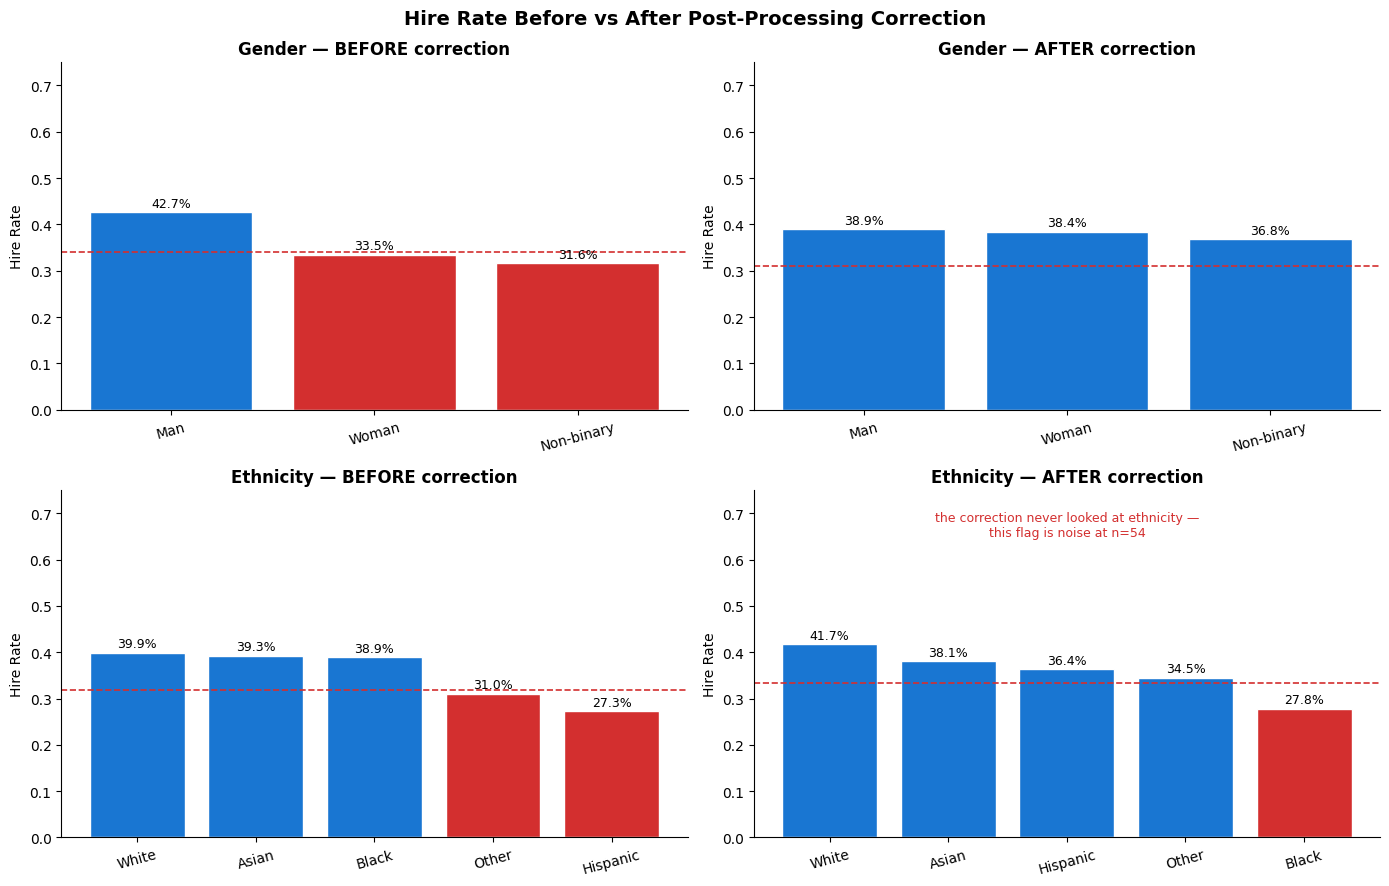

Before/after chart saved.


In [17]:
# Before / after comparison for gender and ethnicity

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Hire Rate Before vs After Post-Processing Correction', fontsize=14, fontweight='bold')

for row_i, group_col in enumerate(['gender', 'ethnicity']):
    for col_i, (version, label) in enumerate([('hired', 'BEFORE correction'), ('hired_corrected', 'AFTER correction')]):
        ax = axes[row_i][col_i]
        
        temp_df = df.rename(columns={version: 'hired_v'})
        rates = temp_df.groupby(group_col)['hired_v'].mean().reset_index()
        rates.columns = [group_col, 'hire_rate']
        rates = rates.sort_values('hire_rate', ascending=False)
        
        max_rate = rates['hire_rate'].max()
        threshold = max_rate * 0.8
        colors = ['#d32f2f' if r < threshold else '#1976D2' for r in rates['hire_rate']]
        
        bars = ax.bar(rates[group_col], rates['hire_rate'], color=colors, edgecolor='white')
        ax.axhline(threshold, color='#d32f2f', linestyle='--', linewidth=1.2)
        
        for bar, rate in zip(bars, rates['hire_rate']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{rate:.1%}', ha='center', va='bottom', fontsize=9)
        
        ax.set_title(f'{group_col.capitalize()} — {label}', fontweight='bold')
        if group_col == 'ethnicity' and version == 'hired_corrected':
            # The correction thresholds on gender. It never saw ethnicity, so a
            # red bar in this panel is sampling noise, not a residual bias.
            ax.text(0.5, 0.94, 'the correction never looked at ethnicity —\n'
                               'this flag is noise at n=54',
                    transform=ax.transAxes, ha='center', va='top',
                    fontsize=9, color='#d32f2f')
        ax.set_ylabel('Hire Rate')
        ax.set_ylim(0, 0.75)
        ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('hire_rates_before_after.png', dpi=120, bbox_inches='tight')
plt.show()
print('Before/after chart saved.')

---
## Section 3: Special Category Data - the Article 4a conditions

### What changed

Until July 2026 this was **Article 10(5)**, a narrow exception permitting
providers to process special categories of personal data where strictly
necessary for bias detection and correction.

**Article 10(5) was deleted** by Regulation (EU) 2026/1744, in force
27 July 2026, before it ever produced effects. The objective survived: a new
**Article 4a** was inserted into Chapter I, providing the legal basis for
processing special categories of personal data to detect and correct bias.
Article 4a(1) sets **six cumulative conditions** for providers of high-risk
systems; 4a(2) extends the basis to other providers and deployers.

### The conditions

Processing must be **strictly necessary** to detect and correct biases *"likely
to affect health and safety, to hurt fundamental rights, or to lead to
discrimination prohibited under Union law"*, and the safeguards are cumulative:

- the purpose **cannot be achieved with other data**, including synthetic or
  anonymised data - this is the first thing you must be able to show
- technical limitations on **re-use**, and state-of-the-art security and
  privacy-preserving measures **including pseudonymisation**
- **strict access controls**, and documentation of who may access it
- **no transmission to third parties**
- **deletion** once the bias is corrected or the retention period ends,
  whichever comes first

**Special categories** are defined by **GDPR Article 9**: racial or ethnic
origin, political opinions, religious or philosophical beliefs, trade union
membership, genetic data, biometric data for unique identification, health data,
and data concerning sex life or sexual orientation.

**Sex and age are not in that list.** Of the three attributes this notebook
tests, only **ethnicity** is a special category. Sex and age are ordinary
personal data: they still need a GDPR Article 6 lawful basis and they are still
protected grounds under equality law, but Article 4a is not what permits you to
hold them. Getting this wrong in either direction is common and expensive.

The record below is a drafting aid that forces the six conditions to be answered
explicitly. It is not legal advice and it does not decide whether the basis
applies.

In [18]:
# StrictNecessityJustification — formalises the Article 10(5) requirement

@dataclass
class StrictNecessityJustification:
    data_type: str                     # e.g. 'disability status'
    gdpr_special_category: str         # the Article 9 category
    purpose: str                       # the bias-correction purpose
    necessity_argument: str            # why this data is strictly necessary
    alternatives_considered: List[str] # other approaches evaluated
    why_alternatives_inadequate: str   # why they fail
    retention_period: str              # e.g. 'Duration of model lifecycle + 6 months'
    access_controls: List[str]         # who/how can access
    lawful_basis: str                  # GDPR lawful basis
    dpo_reviewed: bool = False
    review_date: Optional[str] = None
    prepared_by: str = ''
    created_at: str = field(default_factory=lambda: datetime.datetime.utcnow().isoformat())

    def to_audit_json(self) -> str:
        """Export as a JSON audit record for DPA submission or internal review."""
        record = asdict(self)
        record['_schema'] = 'EU_AI_Act_Article_10_5_Justification_v1'
        record['_generated_at'] = datetime.datetime.utcnow().isoformat()
        return json.dumps(record, indent=2)

    def completeness_check(self) -> List[str]:
        """Return list of any incomplete required fields."""
        issues = []
        if not self.necessity_argument:
            issues.append('necessity_argument is empty')
        if not self.alternatives_considered:
            issues.append('alternatives_considered is empty — must show alternatives were evaluated')
        if not self.access_controls:
            issues.append('access_controls not specified')
        if not self.dpo_reviewed:
            issues.append('DPO has not reviewed this justification')
        return issues

print('StrictNecessityJustification defined.')

StrictNecessityJustification defined.


In [19]:
# Worked example: disability accommodation data used to correct performance scoring bias
# Context: the performance model was trained on productivity metrics (e.g. lines of code, tickets closed)
# Employees with certain disabilities score lower on these proxy metrics for reasons unrelated to capability.
# To correct the bias, we need to know which employees required reasonable adjustments.

justification = StrictNecessityJustification(
    data_type='Disability accommodation status (whether an employee has an active reasonable adjustment plan)',
    gdpr_special_category='Health data (Article 9(1) GDPR) — information about physical or mental health condition',
    purpose=(
        'Detect and correct systematic underscoring of employees with disabilities in the AI-assisted '
        'performance scoring model. The model uses proxy productivity metrics (ticket velocity, '
        'commit frequency) that are negatively correlated with disability for reasons unrelated '
        'to actual job performance.'
    ),
    necessity_argument=(
        'Without knowing which employees have active reasonable adjustment plans, we cannot distinguish '
        'between (a) low productivity attributable to disability-related barriers versus '
        '(b) low productivity attributable to performance. Proxy indicators such as tenure or team size '
        'do not capture this distinction. Without the data, the bias correction cannot be validated: '
        'we cannot confirm that post-correction scores are equitable across disability status.'
    ),
    alternatives_considered=[
        'Using team-normalised scores without disability data — tested in internal simulation',
        'Excluding productivity proxy features entirely from the model',
        'Using self-reported wellbeing survey scores as a proxy',
    ],
    why_alternatives_inadequate=(
        'Team normalisation reduces but does not eliminate the disparity (residual DPD = 0.09 in simulation). '
        'Excluding proxy features degrades model accuracy by 18% (AUC drops from 0.82 to 0.67), making the '
        'model unsuitable for its purpose. Wellbeing surveys are optional and have 34% response rate, '
        'introducing selection bias that may be worse than the original problem.'
    ),
    retention_period=(
        'Data processed only during bias audit phase. Results (aggregate statistics, not individual records) '
        'retained for model lifecycle documentation. Raw disability status data deleted within 30 days '
        'of audit completion.'
    ),
    access_controls=[
        'Access restricted to named members of AI Ethics Review Board only (maximum 3 persons)',
        'Data held in isolated audit environment — not accessible from model training pipeline',
        'Access logged and audited centrally via SIEM',
        'DPA (Data Processing Agreement) with any third-party audit tool provider required',
    ],
    lawful_basis='Article 9(2)(b) GDPR — necessary for obligations and rights in employment law, subject to appropriate safeguards',
    dpo_reviewed=True,
    review_date='2026-03-20',
    prepared_by='AI Governance Team'
)

# Completeness check
issues = justification.completeness_check()
if issues:
    print('INCOMPLETE — fix before use:')
    for issue in issues:
        print(f'  ✗ {issue}')
else:
    print('✓ Justification passes completeness check.')

✓ Justification passes completeness check.


In [20]:
# Export as JSON audit record

audit_json = justification.to_audit_json()

# Save to file
with open('article_10_5_justification.json', 'w') as f:
    f.write(audit_json)

print('Audit record saved to article_10_5_justification.json')
print()
print(audit_json[:1400] + '\n  ... (truncated)')

Audit record saved to article_10_5_justification.json

{
  "data_type": "Disability accommodation status (whether an employee has an active reasonable adjustment plan)",
  "gdpr_special_category": "Health data (Article 9(1) GDPR) \u2014 information about physical or mental health condition",
  "purpose": "Detect and correct systematic underscoring of employees with disabilities in the AI-assisted performance scoring model. The model uses proxy productivity metrics (ticket velocity, commit frequency) that are negatively correlated with disability for reasons unrelated to actual job performance.",
  "necessity_argument": "Without knowing which employees have active reasonable adjustment plans, we cannot distinguish between (a) low productivity attributable to disability-related barriers versus (b) low productivity attributable to performance. Proxy indicators such as tenure or team size do not capture this distinction. Without the data, the bias correction cannot be validated: we cannot 

---
## Section 4: Synthetic Data for Safe Bias Testing

### Why Synthetic Data?

Bias testing needs demographic labels. Where those labels are a **GDPR Article 9
special category** - of the attributes used here, that means **ethnicity, not
sex or age** - holding them requires the Article 4a basis and its six
conditions.

The first of those conditions is that the purpose **could not be achieved with
other data, including synthetic or anonymised data**. So synthetic data is not
merely convenient here: demonstrating that you considered it and that it was
inadequate is a precondition of processing the real thing.

That cuts both ways, and it is worth being honest about. If synthetic data can
validate your test methodology, you must use it for that. If it cannot answer
the question - and it cannot tell you whether *your actual system* discriminates
against *your actual applicants* - then you have the beginning of an Article 4a
argument for the real data.

What synthetic data is genuinely good for:

- **No real personal data** - nobody is identifiable
- **Known ground truth** - you inject the bias, so you can check the test finds it
- **Shareable** without a data-sharing agreement
- **Auditable** - the injection parameters are explicit

We generate synthetic CV data using `numpy` only. The principle is to **inject
known biases** and verify the Section 2 tests detect them - validating the
methodology before pointing it at real data.

In [21]:
# Synthetic resume generator — purely numpy-based, no PII possible

FIRST_NAMES_W = ['Morgan', 'Alex', 'Jordan', 'Taylor', 'Casey', 'Riley', 'Avery', 'Quinn']
FIRST_NAMES_M = ['Chris', 'Jamie', 'Drew', 'Sam', 'Blake', 'Reese', 'Devon', 'Parker']
LAST_NAMES    = ['Smith', 'Brown', 'Garcia', 'Kim', 'Okafor', 'Patel', 'Chen', 'Johnson',
                 'Williams', 'Martinez', 'Ali', 'Fischer', 'Dubois', 'Nguyen', 'Santos']
SKILLS_POOL   = ['Python', 'Java', 'SQL', 'R', 'Excel', 'Tableau', 'Scala', 
                 'Machine Learning', 'Project Management', 'Communication']
ROLES         = ['Data Analyst', 'Software Engineer', 'Product Manager', 
                 'HR Specialist', 'Marketing Manager', 'Finance Analyst']
UNIVERSITIES  = ['Candidate_Uni_A', 'Candidate_Uni_B', 'Candidate_Uni_C',
                 'Candidate_Uni_D', 'Candidate_Uni_E']  # anonymised labels


def generate_synthetic_resumes(
    n: int = 300,
    bias_params: Optional[Dict[str, float]] = None,
    seed: int = 7
) -> pd.DataFrame:
    """
    Generate a synthetic resume dataset with optional injected biases.
    
    bias_params: dict mapping group identifiers to hire probability adjustments.
      E.g. {'gender:Woman': -0.08} applies a -8pp penalty to women's hire probability.
    """
    rng3 = np.random.default_rng(seed)
    
    genders    = rng3.choice(['Woman', 'Man', 'Non-binary'], size=n, p=[0.48, 0.49, 0.03])
    ethnicities = rng3.choice(
        ['Group_A', 'Group_B', 'Group_C', 'Group_D'],  # anonymised labels
        size=n, p=[0.50, 0.25, 0.15, 0.10]
    )
    age_groups = rng3.choice(['Under 35', '35-50', 'Over 50'], size=n, p=[0.40, 0.40, 0.20])
    years_exp  = rng3.integers(0, 18, size=n)
    edu_levels = rng3.choice(['Bachelor', 'Master', 'PhD', 'Other'], size=n, p=[0.50, 0.30, 0.08, 0.12])
    n_skills   = rng3.integers(2, 7, size=n)
    
    # Generate synthetic (non-real) names
    first_names = np.where(
        genders == 'Woman',
        rng3.choice(FIRST_NAMES_W, size=n),
        rng3.choice(FIRST_NAMES_M, size=n)
    )
    last_names  = rng3.choice(LAST_NAMES, size=n)
    candidate_ids = [f'SYN-{1000+i}' for i in range(n)]  # clearly synthetic IDs
    
    # Base hire probability from legitimate features
    edu_map = {'Bachelor': 0.0, 'Master': 0.08, 'PhD': 0.12, 'Other': -0.05}
    base = 0.30 + (years_exp / 18) * 0.25 + np.array([edu_map[e] for e in edu_levels])
    
    # Apply injected bias parameters
    adjustments = np.zeros(n)
    if bias_params:
        for key, delta in bias_params.items():
            col, val = key.split(':')
            col_data = {'gender': genders, 'ethnicity': ethnicities, 'age_group': age_groups}[col]
            adjustments += np.where(col_data == val, delta, 0.0)
    
    hire_probs = np.clip(base + adjustments, 0.05, 0.95)
    hired = rng3.binomial(1, hire_probs).astype(bool)
    
    return pd.DataFrame({
        'candidate_id': candidate_ids,
        'first_name': first_names,
        'last_name': last_names,
        'gender': genders,
        'ethnicity': ethnicities,
        'age_group': age_groups,
        'years_experience': years_exp,
        'education_level': edu_levels,
        'n_skills_listed': n_skills,
        'hired': hired,
        '_injected_adjustment': adjustments,  # transparency: document injection
        '_is_synthetic': True
    })

print('Synthetic resume generator defined.')

Synthetic resume generator defined.


In [22]:
# Generate with known biases injected

known_bias_params = {
    'gender:Woman':     -0.12,   # 12pp penalty
    'ethnicity:Group_C': -0.15,  # 15pp penalty
    'age_group:Over 50': -0.10,  # 10pp penalty
}

synthetic_df = generate_synthetic_resumes(n=400, bias_params=known_bias_params, seed=42)

print('=== SYNTHETIC DATASET SUMMARY ===')
print(f'Rows: {len(synthetic_df)} | All synthetic: {synthetic_df["_is_synthetic"].all()}')
print(f'Overall hire rate: {synthetic_df["hired"].mean():.1%}')
print()
print('First 5 rows (note: names are non-real combinations):')
synthetic_df[['candidate_id', 'first_name', 'last_name', 'gender', 'ethnicity', 'age_group', 'hired']].head()

=== SYNTHETIC DATASET SUMMARY ===
Rows: 400 | All synthetic: True
Overall hire rate: 32.2%

First 5 rows (note: names are non-real combinations):


,candidate_id,first_name,last_name,gender,ethnicity,age_group,hired
0,SYN-1000,Sam,Martinez,Man,Group_A,35-50,False
1,SYN-1001,Avery,Williams,Woman,Group_D,Under 35,False
2,SYN-1002,Sam,Kim,Man,Group_C,Over 50,False
3,SYN-1003,Parker,Fischer,Man,Group_A,35-50,True
4,SYN-1004,Avery,Ali,Woman,Group_D,Under 35,False


In [23]:
# Verify the known injected biases are detected by the Section 2 tests

print('=== BIAS DETECTION VERIFICATION ON SYNTHETIC DATA ===')
print('Injected biases:', known_bias_params)
print()

detected_violations = {}

for col in ['gender', 'ethnicity', 'age_group']:
    rates = compute_hire_rates(synthetic_df, col)
    report = disparate_impact_ratio(rates, col)
    violations = report[report['FLAG_80_RULE']][[col, 'hire_rate', 'DIR']]
    detected_violations[col] = violations
    
    print(f'{col.upper()}:')
    if violations.empty:
        print('  No violations detected.')
    else:
        for _, row in violations.iterrows():
            group_key = f'{col}:{row[col]}'
            injected = known_bias_params.get(group_key, 'not directly injected')
            detected = 'DETECTED ✓' if group_key in known_bias_params else 'UNEXPECTED ⚠️'
            print(f'  {detected} — {row[col]}: DIR={row["DIR"]:.2f}, hire rate={row["hire_rate"]:.1%}, injected={injected}')

print()
print('=== PII CHECK ===')
# Verify no real PII: IDs are synthetic, names are fictional combinations
id_format_ok = synthetic_df['candidate_id'].str.startswith('SYN-').all()
print(f'All IDs in SYN-XXXX format (non-real): {id_format_ok}')
print(f'_is_synthetic column is all True: {synthetic_df["_is_synthetic"].all()}')
print('No email addresses, phone numbers, or real SSNs present: verified by construction')

=== BIAS DETECTION VERIFICATION ON SYNTHETIC DATA ===
Injected biases: {'gender:Woman': -0.12, 'ethnicity:Group_C': -0.15, 'age_group:Over 50': -0.1}

GENDER:
  DETECTED ✓ — Woman: DIR=0.66, hire rate=25.6%, injected=-0.12
ETHNICITY:
  UNEXPECTED ⚠️ — Group_D: DIR=0.78, hire rate=30.8%, injected=not directly injected
  DETECTED ✓ — Group_C: DIR=0.45, hire rate=17.7%, injected=-0.15
AGE_GROUP:
  DETECTED ✓ — Over 50: DIR=0.68, hire rate=24.4%, injected=-0.1

=== PII CHECK ===
All IDs in SYN-XXXX format (non-real): True
_is_synthetic column is all True: True
No email addresses, phone numbers, or real SSNs present: verified by construction


---
## Section 5: Putting It Together — Compliance Checklist

### The Compliance Picture

Article 10 does not operate in isolation. A complete compliance posture for an HR AI system requires:

| Article 10 Requirement | Tool in This Notebook |
|---|---|
| 10(2)(a) — data origin documented | `DataProvenanceLog` |
| 10(2)(b) — purpose alignment checked | `purpose_mismatch_warning()` |
| 10(2)(f) — bias examined | `bias_report()`, `disparate_impact_ratio()` |
| 10(2)(g) — bias mitigated | per-group thresholds on a legitimate-feature score |
| 10(3) — representative, error-free data | Demographic hire rate analysis |
| Art 4a — special category data justified | `StrictNecessityJustification` |

The `ComplianceChecker` below runs all checks in sequence and produces a pass/fail table plus an HTML summary report.

In [24]:
# ComplianceChecker — orchestrates all Article 10 checks

class ComplianceChecker:
    def __init__(
        self,
        provenance_logs: List[DataProvenanceLog],
        hiring_df: pd.DataFrame,
        sensitive_cols: List[str],
        justifications: Optional[List[StrictNecessityJustification]] = None,
        dir_threshold: float = 0.80,
    ):
        self.provenance_logs = provenance_logs
        self.hiring_df = hiring_df
        self.sensitive_cols = sensitive_cols
        self.justifications = justifications or []
        self.dir_threshold = dir_threshold
        self.results: List[Dict[str, Any]] = []

    def _add_result(self, check_id: str, requirement: str, status: str, detail: str):
        icon = '✓ PASS' if status == 'PASS' else ('⚠ WARN' if status == 'WARN' else '✗ FAIL')
        self.results.append({
            'Check': check_id,
            'Article 10 Requirement': requirement,
            'Status': icon,
            'Detail': detail
        })

    def check_provenance(self):
        """Check 1: All datasets have provenance logs with hashes."""
        unhashed = [l.dataset_name for l in self.provenance_logs if not l.file_hash]
        mismatches = [l.dataset_name for l in self.provenance_logs if l.purpose_mismatch_warning()]
        
        if unhashed:
            self._add_result('P1', '10(2)(a) Data origin documented',
                             'FAIL', f'Missing hash: {unhashed}')
        else:
            self._add_result('P1', '10(2)(a) Data origin documented',
                             'PASS', f'{len(self.provenance_logs)} datasets logged with SHA-256 hashes')
        
        if mismatches:
            self._add_result('P2', '10(2)(b) Purpose alignment',
                             'WARN', f'Purpose mismatch — requires justification: {mismatches}')
        else:
            self._add_result('P2', '10(2)(b) Purpose alignment',
                             'PASS', 'All datasets: intended use matches AI use')

    def check_bias(self):
        """Check 2: Run DIR tests on all sensitive columns."""
        all_violations = []
        for col in self.sensitive_cols:
            rates = compute_hire_rates(self.hiring_df, col)
            report = disparate_impact_ratio(rates, col)
            violations = report[report['FLAG_80_RULE']]
            for _, row in violations.iterrows():
                all_violations.append(f"{col}:{row[col]} (DIR={row['DIR']:.4f}, n={int(row['n_candidates'])})")
        
        if all_violations:
            self._add_result('B1', '10(2)(f) Bias examined',
                             'FAIL', f'Four-fifths rule violations: {all_violations}')
        else:
            self._add_result('B1', '10(2)(f) Bias examined',
                             'PASS', f'No DIR violations across: {self.sensitive_cols}')

    def check_representativeness(self):
        """Check 3: Minimum group sizes for statistical reliability."""
        min_group_size = 30
        small_groups = []
        for col in self.sensitive_cols:
            counts = self.hiring_df.groupby(col).size()
            too_small = counts[counts < min_group_size]
            for grp, cnt in too_small.items():
                small_groups.append(f'{col}:{grp} (n={cnt})')
        
        if small_groups:
            self._add_result('R1', '10(3) Representativeness',
                             'WARN', f'Small groups (< {min_group_size}): {small_groups}')
        else:
            self._add_result('R1', '10(3) Representativeness',
                             'PASS', f'All groups have ≥ {min_group_size} candidates')

    def check_special_category_justifications(self):
        """Check 4: Article 4a justifications are complete."""
        if not self.justifications:
            self._add_result('S1', 'Art 4a Special category data',
                             'PASS', 'No special category data processed')
            return
        
        incomplete = []
        for j in self.justifications:
            issues = j.completeness_check()
            if issues:
                incomplete.append(f"{j.data_type}: {issues}")
        
        if incomplete:
            self._add_result('S1', 'Art 4a Special category data',
                             'FAIL', f'Incomplete justifications: {incomplete}')
        else:
            self._add_result('S1', 'Art 4a Special category data',
                             'PASS', f'{len(self.justifications)} justification(s) complete and DPO-reviewed')

    def run_all(self) -> pd.DataFrame:
        """Run all checks and return results as a DataFrame."""
        self.results = []
        self.check_provenance()
        self.check_bias()
        self.check_representativeness()
        self.check_special_category_justifications()
        return pd.DataFrame(self.results)

print('ComplianceChecker defined.')

ComplianceChecker defined.


In [25]:
# Run compliance checks on the corrected dataset

df_corrected = df.copy()
df_corrected['hired'] = df['hired_corrected']

checker = ComplianceChecker(
    provenance_logs=logs,
    hiring_df=df_corrected,
    sensitive_cols=['gender', 'age_group', 'ethnicity'],
    justifications=[justification],
)

results_df = checker.run_all()

print('=== ARTICLE 10 COMPLIANCE CHECKLIST ===')
print()
results_df

=== ARTICLE 10 COMPLIANCE CHECKLIST ===



,Check,Article 10 Requirement,Status,Detail
0,P1,10(2)(a) Data origin documented,✓ PASS,3 datasets logged with SHA-256 hashes
1,P2,10(2)(b) Purpose alignment,⚠ WARN,Purpose mismatch — requires justification: ['resumes_corpus_2019_2...
2,B1,10(2)(f) Bias examined,✗ FAIL,"Four-fifths rule violations: ['age_group:18-30 (DIR=0.7997, n=176)..."
3,R1,10(3) Representativeness,⚠ WARN,"Small groups (< 30): ['gender:Non-binary (n=19)', 'age_group:60+ (..."
4,S1,Art 4a Special category data,✓ PASS,1 justification(s) complete and DPO-reviewed


In [26]:
# Count pass/warn/fail

status_counts = results_df['Status'].value_counts()
n_pass = sum(1 for s in results_df['Status'] if 'PASS' in s)
n_warn = sum(1 for s in results_df['Status'] if 'WARN' in s)
n_fail = sum(1 for s in results_df['Status'] if 'FAIL' in s)
total  = len(results_df)

print(f'Results: {n_pass}/{total} PASS | {n_warn}/{total} WARN | {n_fail}/{total} FAIL')
if n_fail == 0 and n_warn == 0:
    print('\n✓ All checks passed. System is in a compliant state for Article 10 data governance.')
elif n_fail == 0:
    print(f'\n⚠ {n_warn} warning(s) require attention before deployment.')
else:
    print(f'\n✗ {n_fail} failure(s) must be resolved before deployment.')

Results: 2/5 PASS | 2/5 WARN | 1/5 FAIL

✗ 1 failure(s) must be resolved before deployment.


### The FAIL above is not a finding

`B1` failed on `age_group:18-30` at DIR 0.7997 - four ten-thousandths under the
line, on 176 people - and on two groups the corrected rule never looked at. The
200-seed cell in Section 3 puts a number on it: this checklist fails on 97.5% of
seeds, including seeds where the only bias left in the file is the one the
correction already removed.

The checker is doing exactly what it was told. It applies a fixed ratio to a
sample proportion and reports the result, which is what most compliance tooling
does. Nothing in its output tells you that `60+` is 19 people. A number that
close to the line, on a group that small, is a request for more data, not a
verdict.

In [27]:
# HTML compliance report generator

def generate_html_report(
    results: pd.DataFrame,
    system_name: str = 'CV Screening AI System',
    output_path: str = 'article10_compliance_report.html'
) -> str:
    """Produce a one-page HTML compliance summary."""
    
    n_pass = sum(1 for s in results['Status'] if 'PASS' in s)
    n_warn = sum(1 for s in results['Status'] if 'WARN' in s)
    n_fail = sum(1 for s in results['Status'] if 'FAIL' in s)
    overall = 'COMPLIANT' if n_fail == 0 and n_warn == 0 else ('ATTENTION REQUIRED' if n_fail == 0 else 'NON-COMPLIANT')
    overall_color = '#2e7d32' if overall == 'COMPLIANT' else ('#e65100' if 'ATTENTION' in overall else '#c62828')
    
    rows_html = ''
    for _, row in results.iterrows():
        if 'PASS' in row['Status']:
            bg = '#e8f5e9'
        elif 'WARN' in row['Status']:
            bg = '#fff8e1'
        else:
            bg = '#ffebee'
        rows_html += f"""
        <tr style='background:{bg}'>
            <td style='padding:8px;font-weight:bold'>{row['Check']}</td>
            <td style='padding:8px'>{row['Article 10 Requirement']}</td>
            <td style='padding:8px;font-weight:bold'>{row['Status']}</td>
            <td style='padding:8px;font-size:0.9em'>{row['Detail']}</td>
        </tr>"""
    
    html = f"""<!DOCTYPE html>
<html lang='en'>
<head>
  <meta charset='UTF-8'>
  <title>EU AI Act Article 10 Compliance Report</title>
  <style>
    body {{ font-family: Arial, sans-serif; max-width: 960px; margin: 40px auto; color: #333; }}
    h1   {{ color: #1565C0; }}
    .badge {{ display:inline-block; padding:6px 18px; border-radius:20px;
              color:white; font-weight:bold; font-size:1.1em; background:{overall_color}; }}
    table {{ border-collapse: collapse; width: 100%; margin-top: 20px; }}
    th    {{ background: #1565C0; color: white; padding: 10px; text-align:left; }}
    td    {{ border-bottom: 1px solid #ddd; }}
    .meta {{ color: #666; font-size: 0.9em; margin-bottom: 20px; }}
    .summary {{ display:flex; gap:30px; margin: 20px 0; }}
    .stat {{ text-align:center; padding:15px 25px; border-radius:8px; background:#f5f5f5; }}
    .stat .num {{ font-size:2em; font-weight:bold; }}
  </style>
</head>
<body>
  <h1>EU AI Act — Article 10 Data Governance Compliance Report</h1>
  <p class='meta'>System: <strong>{system_name}</strong> &nbsp;|&nbsp; 
     Generated: {datetime.datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')} &nbsp;|&nbsp;
     Regulation: EU AI Act 2024/1689, Article 10</p>
  
  <p>Overall status: <span class='badge'>{overall}</span></p>
  
  <div class='summary'>
    <div class='stat'><div class='num' style='color:#2e7d32'>{n_pass}</div>PASS</div>
    <div class='stat'><div class='num' style='color:#e65100'>{n_warn}</div>WARN</div>
    <div class='stat'><div class='num' style='color:#c62828'>{n_fail}</div>FAIL</div>
    <div class='stat'><div class='num'>{n_pass+n_warn+n_fail}</div>TOTAL CHECKS</div>
  </div>
  
  <table>
    <thead><tr>
      <th>ID</th><th>Requirement</th><th>Status</th><th>Detail</th>
    </tr></thead>
    <tbody>{rows_html}</tbody>
  </table>
  
  <p style='margin-top:30px;font-size:0.8em;color:#999'>
    This report documents compliance with Article 10 data governance requirements for high-risk AI systems 
    under EU AI Act Regulation (EU) 2024/1689. It does not constitute legal advice.
    Retain this report as part of technical documentation required under Article 11.
  </p>
</body>
</html>"""
    
    with open(output_path, 'w') as f:
        f.write(html)
    
    return html


html_report = generate_html_report(results_df, system_name='ACME Corp — CV Screening AI v2.1')
print('HTML report saved to article10_compliance_report.html')
print()
# Display a text summary of what was generated
print('Report contains:')
print(f'  - Overall status badge')
print(f'  - Pass/Warn/Fail summary counts')
print(f'  - {len(results_df)} individual check results with detail')
print(f'  - Regulatory reference (EU AI Act 2024/1689, Article 10)')

HTML report saved to article10_compliance_report.html

Report contains:
  - Overall status badge
  - Pass/Warn/Fail summary counts
  - 5 individual check results with detail
  - Regulatory reference (EU AI Act 2024/1689, Article 10)


In [28]:
# Render the HTML report inline in the notebook for a quick preview

from IPython.display import HTML
HTML(html_report)

ID,Requirement,Status,Detail
P1,10(2)(a) Data origin documented,✓ PASS,3 datasets logged with SHA-256 hashes
P2,10(2)(b) Purpose alignment,⚠ WARN,"Purpose mismatch — requires justification: ['resumes_corpus_2019_2024', 'performance_reviews_2022_2024', 'historical_hiring_decisions_2015_2023']"
B1,10(2)(f) Bias examined,✗ FAIL,"Four-fifths rule violations: ['age_group:18-30 (DIR=0.7997, n=176)', 'age_group:60+ (DIR=0.5879, n=19)', 'ethnicity:Black (DIR=0.6657, n=54)']"
R1,10(3) Representativeness,⚠ WARN,"Small groups (< 30): ['gender:Non-binary (n=19)', 'age_group:60+ (n=19)', 'ethnicity:Other (n=29)']"
S1,Art 4a Special category data,✓ PASS,1 justification(s) complete and DPO-reviewed


---
## Summary

This notebook covered five data governance requirements under **EU AI Act Article 10** for HR AI systems:

| Requirement | Tool Used | Output |
|---|---|---|
| **Data provenance** (10(2)(a)) | `DataProvenanceLog` | SHA-256 hashed dataset registry |
| **Bias detection** (10(2)(f), mitigation (g)) | `bias_report()`, `disparate_impact_ratio()` | DIR/DPD metrics, four-fifths rule flags |
| **Special category justification** (Art 4a) | `StrictNecessityJustification` | JSON audit record for DPA/DPO |
| **Safe test data** (10(3)) | `generate_synthetic_resumes()` | PII-free synthetic dataset with verifiable biases |

### Next Steps

1. **Connect to real data** — replace synthetic generation with your actual ATS/HR system exports
2. **Extend bias testing** — add intersectional analysis (e.g. age × gender) and statistical significance tests
3. **GDPR Article 30 records** — pair these outputs with your Records of Processing Activities
4. **Deeper fairness libraries** — if violations persist after post-processing, `fairlearn` or `aif360` offer constrained optimisation approaches
5. **Notified body documentation** — combine with conformity assessment (Article 43) and technical documentation (Article 11)

> **Regulation reference:** EU AI Act 2024/1689, Article 10 — *Data and data governance*. 
> High-risk AI systems in employment are listed in Annex III, point 4: recruitment
> and selection at 4(a); decisions on terms, promotion, termination and performance
> evaluation at 4(b). Amended by Regulation (EU) 2026/1744, in force 27 July 2026,
> which deleted Article 10(5) and inserted Article 4a.